<a href="https://colab.research.google.com/github/mrupendrakushwaha/AI-Powered-Weather-Forecasting-using-Machine-Learning/blob/main/%F0%9F%8C%A6%EF%B8%8F_AI_Powered_Weather_Forecasting_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📚 Import Libraries

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📂 Dataset Loading

In [153]:
df = pd.read_csv('/content/seattle-weather.csv')

# 🔍 Exploratory Data Analysis (EDA)

In [154]:
display(df.head())

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


Checking whether the dataset got imported to the notebook.

In [155]:
df.shape

(1461, 6)

In [156]:
df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [157]:
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


In [158]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   object 
dtypes: float64(4), object(2)
memory usage: 68.6+ KB


In [159]:
df.isnull().sum()

,0
date,0
precipitation,0
temp_max,0
temp_min,0
wind,0
weather,0


There are no null values in the data set.

# 🛠 Data Preprocessing

In [160]:
from sklearn.preprocessing import LabelEncoder

df['weather']=LabelEncoder().fit_transform(df['weather'])

# 📊 Data Visualization

<Axes: >

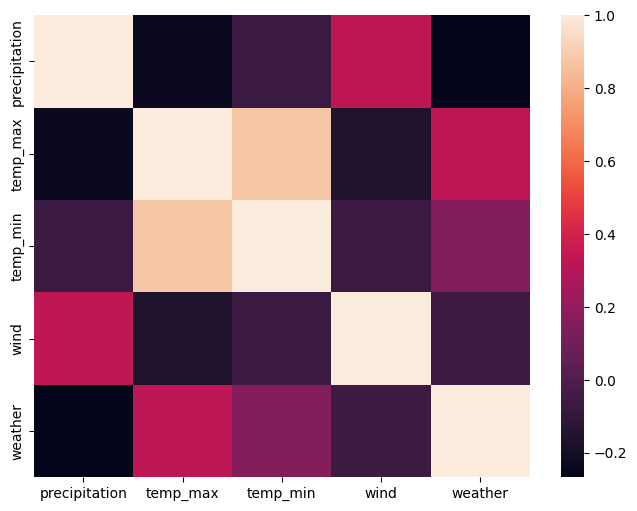

In [161]:
fig, axes=plt.subplots(figsize=(8, 6))
sns.heatmap(df.drop('date', axis=1).corr(), ax=axes)

We can observe that wind and preception are weakly co-related.temp_max and wind are negatively correlated means they move in the opposite direction.


# 🤖 Machine Learning Model

In [162]:
from sklearn.model_selection import train_test_split
features=["precipitation", "temp_max", "temp_min", "wind"]
X=df[features]
y=df.weather
train_X, test_X, train_y, test_y = train_test_split(X, y,random_state = 0)

# 📈 Model Accuracy

In [163]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(random_state=1)

model.fit(train_X, train_y)

pred = model.predict(test_X)

print("Accuracy:", accuracy_score(test_y, pred))

Accuracy: 0.8005464480874317


# 📋 Classification Report

In [164]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(classification_report(test_y, pred))
print(confusion_matrix(test_y, pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.07      0.03      0.04        31
           2       0.96      0.93      0.94       155
           3       1.00      0.33      0.50         6
           4       0.75      0.90      0.82       163

    accuracy                           0.80       366
   macro avg       0.56      0.44      0.46       366
weighted avg       0.76      0.80      0.78       366

[[  0   0   0   0  11]
 [  1   1   1   0  28]
 [  0   1 144   0  10]
 [  0   0   4   2   0]
 [  4  12   1   0 146]]


# 🔲 Confusion Matrix

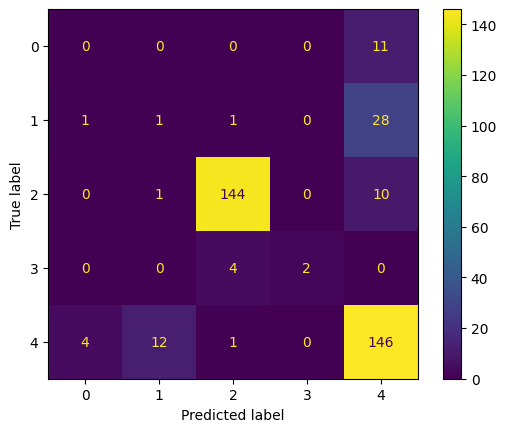

In [165]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(test_y, pred)
plt.show()

# 📊 Weather Distribution

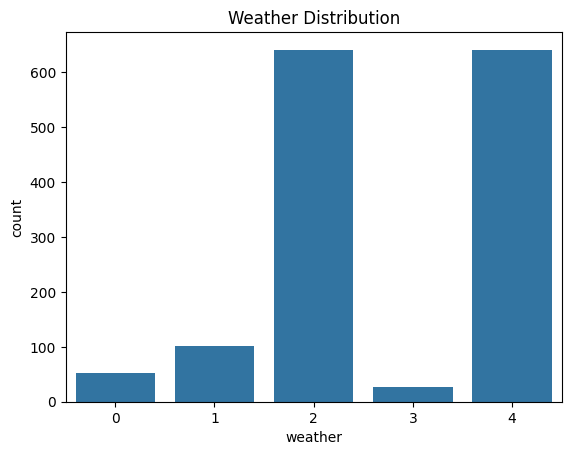

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='weather', data=df)
plt.title("Weather Distribution")
plt.show()

# 📈 Feature Importance Analysis

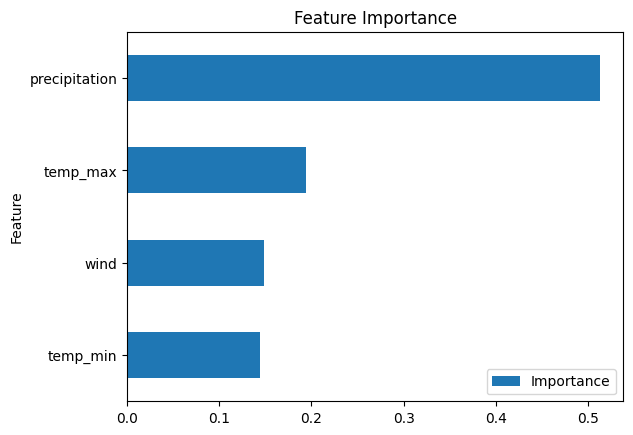

In [167]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance.sort_values('Importance').plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title("Feature Importance")
plt.show()

# 🌦 Weather Prediction Input

In [168]:
precipitation = float(input("Precipitation: "))
temp_max = float(input("Max Temperature: "))
temp_min = float(input("Min Temperature: "))
wind = float(input("Wind Speed: "))

input_data = [[precipitation, temp_max, temp_min, wind]]

result = model.predict(input_data)

Precipitation: 10
Max Temperature: 0
Min Temperature: -5
Wind Speed: 5


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# 🌦 Weather Prediction Output

In [169]:
from IPython.display import Image, display

weather_labels = {
    0: "drizzle",
    1: "fog",
    2: "rain",
    3: "snow",
    4: "sun"
}

weather = weather_labels[int(result[0])]
print("Predicted Weather:", weather)
if weather == "rain":
    display(Image(url="https://cdn-icons-png.flaticon.com/512/3351/3351979.png"))

elif weather == "sun":
    display(Image(url="https://cdn-icons-png.flaticon.com/512/869/869869.png"))

elif weather == "fog":
    display(Image(url="https://cdn-icons-png.flaticon.com/512/4005/4005901.png"))

elif weather == "snow":
    display(Image(url="https://cdn-icons-png.flaticon.com/512/642/642102.png"))

elif weather == "drizzle":
    display(Image(url="https://cdn-icons-png.flaticon.com/512/414/414974.png"))

Predicted Weather: snow
